# *Laboratório II (n2) - Processamento Digital de Imagens -  Prof. Dr. Cassio Vinhal*

Pedro Cézar S. Ferreira -  202302579 - Eng. de Computação

# Aplicação Prática: Estimação Cega de Ruído Gaussiano em Imagens Reais


### Pergunta condutora

> *Como aplicar as técnicas de estimação cega de ruído aprendidas no Lab I para analisar imagens reais com diferentes tipos e níveis de ruído?*

### Roteiro

- **Parte A** — Preparação (imports, carregamento das imagens)
- **Parte B** — Análise visual: comparação entre imagens limpas e ruidosas
- **Parte C** — Estimação cega de ruído gaussiano (σ=25) com os três estimadores
- **Parte D** — Comportamento dos estimadores diante de ruído sal-e-pimenta
- **Parte E** — Comparação FullHD vs 4K: influência da resolução
- **Parte F** — Fechamento e perguntas


## Parte A: Preparação

Vamos carregar as seis imagens do diretório `imagens_cinza_pdi_filtragem/`:
- **imagemAFullHD_base.png** — imagem limpa (1920×1080)
- **imagemAFullHD_ruido_gaussiano_sigma25.png** — ruído gaussiano σ=25 (escala 0–255)
- **imagemAFullHD_ruido_sal_pimenta_10pct.png** — ruído sal-e-pimenta 10%
- **imagemA4K_base.png** — imagem limpa (3840×2160)
- **imagemA4K_ruido_gaussiano_sigma25.png** — ruído gaussiano σ=25 (escala 0–255)
- **imagemA4K_ruido_sal_pimenta_10pct.png** — ruído sal-e-pimenta 10%


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import pandas as pd
import os

# semente para reprodutibilidade
rng = np.random.default_rng(42)

# diretorio das imagens
IMG_DIR = 'imagens_cinza_pdi_filtragem'

def carregar_imagem(nome):
    """Carrega imagem em escala de cinza e normaliza para [0, 1]."""
    caminho = os.path.join(IMG_DIR, nome)
    img = Image.open(caminho).convert('L')  # garante escala de cinza
    arr = np.array(img, dtype=np.float64) / 255.0
    return arr

# carrega todas as imagens
# --- FullHD ---
fhd_base    = carregar_imagem('imagemAFullHD_base.png')
fhd_gauss   = carregar_imagem('imagemAFullHD_ruido_gaussiano_sigma25.png')
fhd_sp      = carregar_imagem('imagemAFullHD_ruido_sal_pimenta_10pct.png')

# --- 4K ---
k4_base     = carregar_imagem('imagemA4K_base.png')
k4_gauss    = carregar_imagem('imagemA4K_ruido_gaussiano_sigma25.png')
k4_sp       = carregar_imagem('imagemA4K_ruido_sal_pimenta_10pct.png')

# imprime informacoes basicas
print('=== Imagens FullHD ===')
print(f'Base:     shape={fhd_base.shape}, dtype={fhd_base.dtype}, μ={fhd_base.mean():.4f}, σ={fhd_base.std():.4f}')
print(f'Gauss25:  shape={fhd_gauss.shape}, dtype={fhd_gauss.dtype}, μ={fhd_gauss.mean():.4f}, σ={fhd_gauss.std():.4f}')
print(f'S&P 10%:  shape={fhd_sp.shape}, dtype={fhd_sp.dtype}, μ={fhd_sp.mean():.4f}, σ={fhd_sp.std():.4f}')
print()
print('=== Imagens 4K ===')
print(f'Base:     shape={k4_base.shape}, dtype={k4_base.dtype}, μ={k4_base.mean():.4f}, σ={k4_base.std():.4f}')
print(f'Gauss25:  shape={k4_gauss.shape}, dtype={k4_gauss.dtype}, μ={k4_gauss.mean():.4f}, σ={k4_gauss.std():.4f}')
print(f'S&P 10%:  shape={k4_sp.shape}, dtype={k4_sp.dtype}, μ={k4_sp.mean():.4f}, σ={k4_sp.std():.4f}')


=== Imagens FullHD ===
Base:     shape=(1080, 1920), dtype=float64, μ=0.5015, σ=0.1954
Gauss25:  shape=(1080, 1920), dtype=float64, μ=0.4994, σ=0.2169
S&P 10%:  shape=(1080, 1920), dtype=float64, μ=0.5013, σ=0.2436

=== Imagens 4K ===
Base:     shape=(2160, 3840), dtype=float64, μ=0.5003, σ=0.1942
Gauss25:  shape=(2160, 3840), dtype=float64, μ=0.4984, σ=0.2159
S&P 10%:  shape=(2160, 3840), dtype=float64, μ=0.5002, σ=0.2427


## Parte B: Análise Visual — Comparação entre imagens limpas e ruidosas

Antes de aplicar os estimadores, vamos visualizar as imagens para entender qualitativamente o efeito de cada tipo de ruído.

### B.1: Imagens FullHD


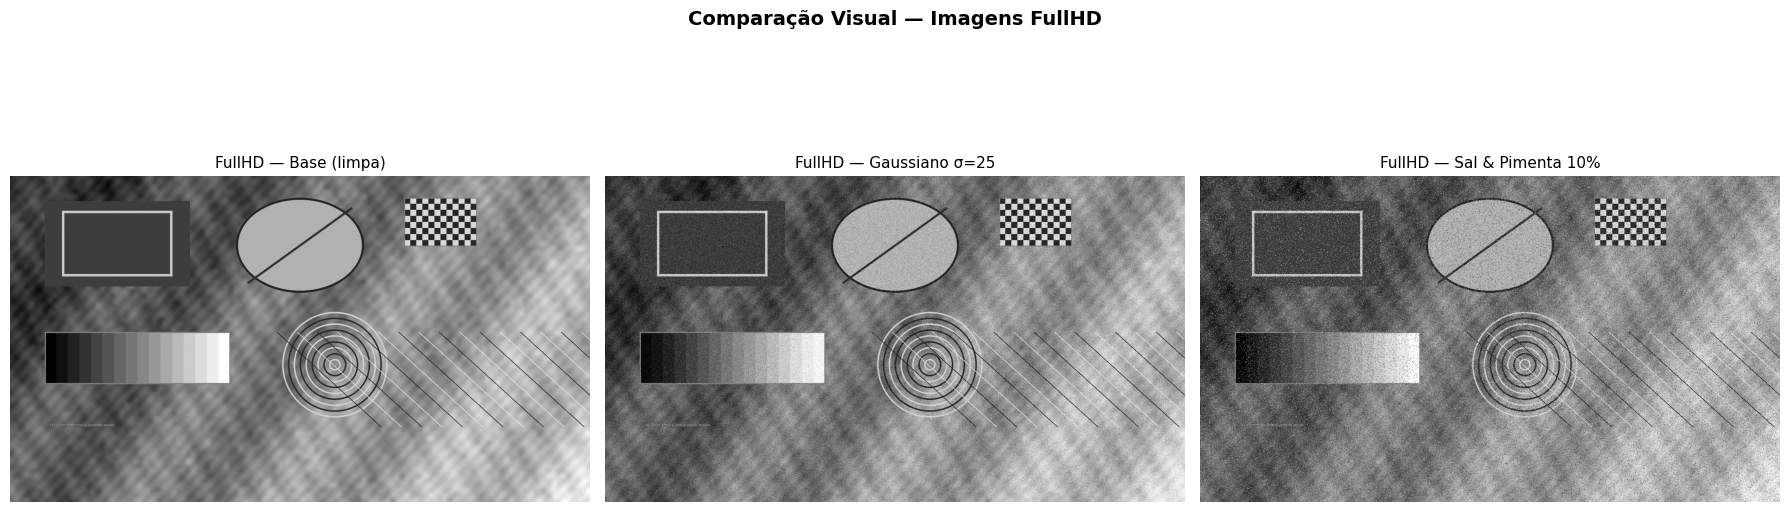

In [2]:
# comparacao visual das 3 imagens FullHD
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titulos_fhd = ['FullHD — Base (limpa)', 'FullHD — Gaussiano σ=25', 'FullHD — Sal & Pimenta 10%']
imagens_fhd = [fhd_base, fhd_gauss, fhd_sp]

for ax, img, titulo in zip(axes, imagens_fhd, titulos_fhd):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(titulo, fontsize=11)
    ax.axis('off')

plt.suptitle('Comparação Visual — Imagens FullHD', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### B.2: Imagens 4K


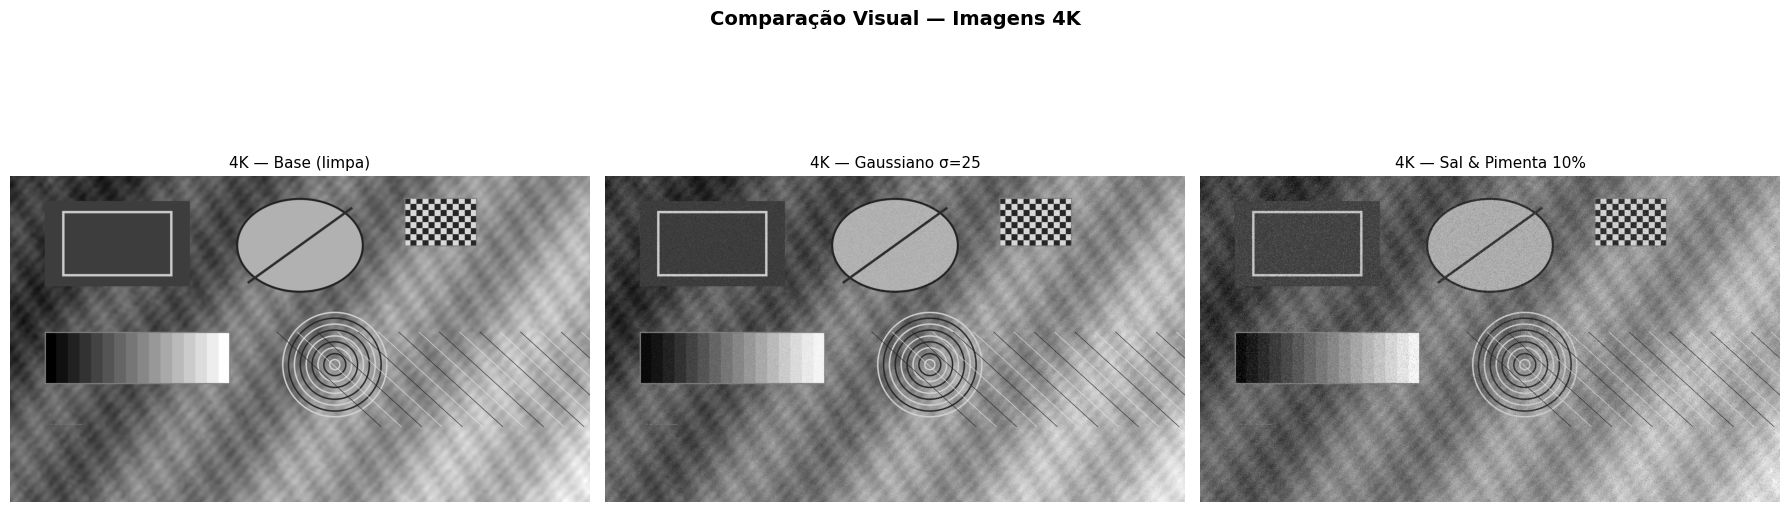

In [3]:
# comparacao visual das 3 imagens 4K
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

titulos_4k = ['4K — Base (limpa)', '4K — Gaussiano σ=25', '4K — Sal & Pimenta 10%']
imagens_4k = [k4_base, k4_gauss, k4_sp]

for ax, img, titulo in zip(axes, imagens_4k, titulos_4k):
    ax.imshow(img, cmap='gray', vmin=0, vmax=1)
    ax.set_title(titulo, fontsize=11)
    ax.axis('off')

plt.suptitle('Comparação Visual — Imagens 4K', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### B.3: Zoom em regiões de detalhe

Para visualizar melhor o efeito do ruído, vamos recortar e ampliar uma região de cada imagem FullHD.


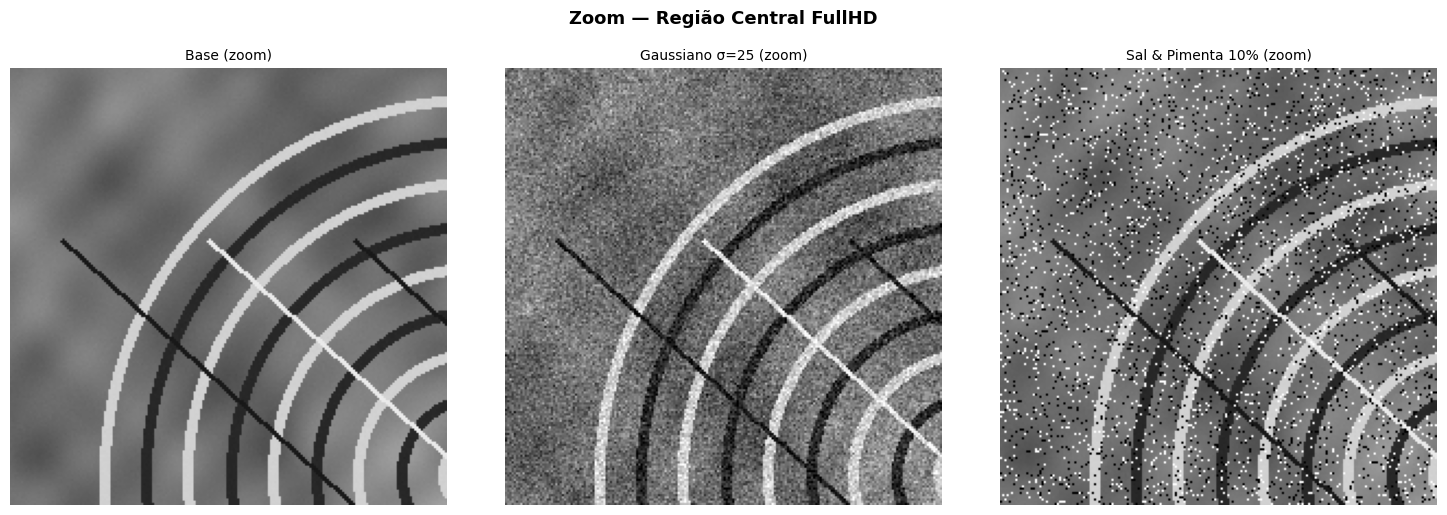

In [4]:
# recorte para zoom (regiao central 200x200 pixels)
h, w = fhd_base.shape
cy, cx = h // 2, w // 2
tamanho_recorte = 200
y1, y2 = cy - tamanho_recorte // 2, cy + tamanho_recorte // 2
x1, x2 = cx - tamanho_recorte // 2, cx + tamanho_recorte // 2

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

recortes_fhd = [fhd_base[y1:y2, x1:x2], fhd_gauss[y1:y2, x1:x2], fhd_sp[y1:y2, x1:x2]]
titulos_zoom = ['Base (zoom)', 'Gaussiano σ=25 (zoom)', 'Sal & Pimenta 10% (zoom)']

for ax, rec, titulo in zip(axes, recortes_fhd, titulos_zoom):
    ax.imshow(rec, cmap='gray', vmin=0, vmax=1)
    ax.set_title(titulo, fontsize=10)
    ax.axis('off')

plt.suptitle('Zoom — Região Central FullHD', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


## Parte C: Estimação cega de ruído gaussiano

Vamos aplicar os **três estimadores** estudados no Lab I:

1. **Global (std)** — `np.std(g)` — o estimador ingênuo que mede a variabilidade total da imagem
2. **Diferenças (diff)** — desvio-padrão das diferenças entre pixels vizinhos, dividido por √2
3. **MAD** — Desvio Absoluto Mediano das diferenças, corrigido pelos fatores 0,6745 e √2 (resultando em divisão por 0,9539)

### Definição dos estimadores


In [5]:
def estimar_sigma_global(img):
    """Estimador ingênuo: desvio-padrao global da imagem."""
    return img.std()

def estimar_sigma_diff(img):
    """Estimador por diferenças entre pixels vizinhos.
    Subtraindo pixels vizinhos, a estrutura lenta da imagem se cancela
    e sobra basicamente o ruido. Se o ruido tem desvio sigma,
    a diferenca de dois pixels vizinhos ruidosos tem desvio sqrt(2)*sigma."""
    d = np.diff(img, axis=1)
    return d.std() / np.sqrt(2)

def estimar_sigma_mad(img):
    """Estimador MAD (Median Absolute Deviation).
    A mediana e robusta a outliers (bordas reais). Usamos:
    sigma = MAD / 0.9539
    onde 0.9539 = 0.6745 * sqrt(2)
    (0.6745 e a razao entre MAD e sigma para a normal padrao)."""
    d = np.diff(img, axis=1).ravel()
    mad = np.median(np.abs(d - np.median(d)))
    return mad / 0.9539

print('Estimadores definidos com sucesso.')


Estimadores definidos com sucesso.


### C.1: Estimação nas imagens com ruído gaussiano σ=25

O ruído gaussiano foi adicionado com σ=25 na escala 0–255. Na nossa escala normalizada [0,1], isso equivale a:

$$\sigma_{\text{normalizado}} = \frac{25}{255} \approx 0{,}0980$$

Vamos aplicar os três estimadores nas imagens FullHD e 4K com ruído gaussiano e comparar com o valor verdadeiro.


In [6]:
# sigma verdadeiro do ruido gaussiano (sigma=25 na escala 0-255)
sigma_verdadeiro = 25.0 / 255.0

print(f'σ verdadeiro (normalizado): {sigma_verdadeiro:.4f}')
print(f'σ verdadeiro (escala 0-255): 25')
print()

# --- FullHD ---
sigma_global_fhd = estimar_sigma_global(fhd_gauss)
sigma_diff_fhd   = estimar_sigma_diff(fhd_gauss)
sigma_mad_fhd    = estimar_sigma_mad(fhd_gauss)

print('=== FullHD — Ruído Gaussiano σ=25 ===')
print(f'σ global (std):   {sigma_global_fhd:.4f}  (erro: {abs(sigma_global_fhd - sigma_verdadeiro):.4f})')
print(f'σ diferenças:     {sigma_diff_fhd:.4f}  (erro: {abs(sigma_diff_fhd - sigma_verdadeiro):.4f})')
print(f'σ MAD:            {sigma_mad_fhd:.4f}  (erro: {abs(sigma_mad_fhd - sigma_verdadeiro):.4f})')
print()

# --- 4K ---
sigma_global_4k = estimar_sigma_global(k4_gauss)
sigma_diff_4k   = estimar_sigma_diff(k4_gauss)
sigma_mad_4k    = estimar_sigma_mad(k4_gauss)

print('=== 4K — Ruído Gaussiano σ=25 ===')
print(f'σ global (std):   {sigma_global_4k:.4f}  (erro: {abs(sigma_global_4k - sigma_verdadeiro):.4f})')
print(f'σ diferenças:     {sigma_diff_4k:.4f}  (erro: {abs(sigma_diff_4k - sigma_verdadeiro):.4f})')
print(f'σ MAD:            {sigma_mad_4k:.4f}  (erro: {abs(sigma_mad_4k - sigma_verdadeiro):.4f})')


σ verdadeiro (normalizado): 0.0980
σ verdadeiro (escala 0-255): 25

=== FullHD — Ruído Gaussiano σ=25 ===
σ global (std):   0.2169  (erro: 0.1188)
σ diferenças:     0.1022  (erro: 0.0042)
σ MAD:            0.0987  (erro: 0.0006)

=== 4K — Ruído Gaussiano σ=25 ===
σ global (std):   0.2159  (erro: 0.1178)
σ diferenças:     0.0997  (erro: 0.0017)
σ MAD:            0.0987  (erro: 0.0006)


### C.2: Tabela comparativa — Ruído Gaussiano


In [7]:
# monta tabela comparativa para ruido gaussiano
dados_gauss = {
    'Resolução': ['FullHD', '4K'],
    'σ verdadeiro': [sigma_verdadeiro, sigma_verdadeiro],
    'global (std)': [sigma_global_fhd, sigma_global_4k],
    'diff': [sigma_diff_fhd, sigma_diff_4k],
    'MAD': [sigma_mad_fhd, sigma_mad_4k],
}

df_gauss = pd.DataFrame(dados_gauss)

# calcula erros absolutos
df_gauss['|erro| global'] = abs(df_gauss['global (std)'] - df_gauss['σ verdadeiro'])
df_gauss['|erro| diff']   = abs(df_gauss['diff'] - df_gauss['σ verdadeiro'])
df_gauss['|erro| MAD']    = abs(df_gauss['MAD'] - df_gauss['σ verdadeiro'])

print('Tabela Comparativa — Ruído Gaussiano σ=25 (normalizado para [0,1]):')
print()
print(df_gauss.to_string(index=False, float_format='{:.4f}'.format))


Tabela Comparativa — Ruído Gaussiano σ=25 (normalizado para [0,1]):

Resolução  σ verdadeiro  global (std)   diff    MAD  |erro| global  |erro| diff  |erro| MAD
   FullHD        0.0980        0.2169 0.1022 0.0987         0.1188       0.0042      0.0006
       4K        0.0980        0.2159 0.0997 0.0987         0.1178       0.0017      0.0006


### C.3: Gráfico comparativo


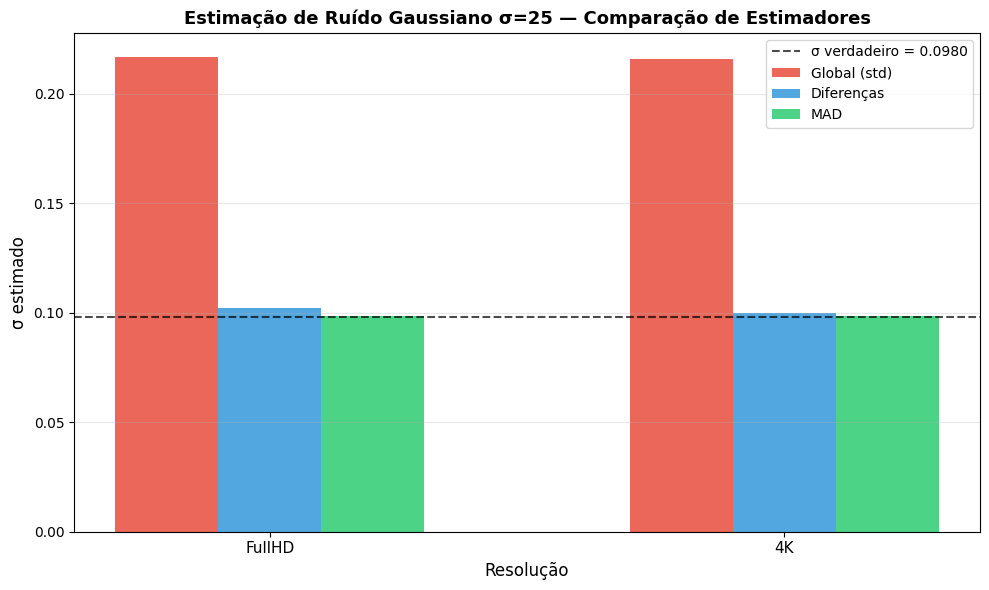

In [8]:
# grafico de barras comparando os 3 estimadores nas 2 resoluções
fig, ax = plt.subplots(figsize=(10, 6))

resolucoes = ['FullHD', '4K']
x = np.arange(len(resolucoes))
largura = 0.2

vals_global = [sigma_global_fhd, sigma_global_4k]
vals_diff   = [sigma_diff_fhd, sigma_diff_4k]
vals_mad    = [sigma_mad_fhd, sigma_mad_4k]

bars1 = ax.bar(x - largura, vals_global, largura, label='Global (std)', color='#e74c3c', alpha=0.85)
bars2 = ax.bar(x,           vals_diff,   largura, label='Diferenças',   color='#3498db', alpha=0.85)
bars3 = ax.bar(x + largura, vals_mad,    largura, label='MAD',          color='#2ecc71', alpha=0.85)

# linha do sigma verdadeiro
ax.axhline(y=sigma_verdadeiro, color='black', linestyle='--', linewidth=1.5, label=f'σ verdadeiro = {sigma_verdadeiro:.4f}', alpha=0.7)

ax.set_xlabel('Resolução', fontsize=12)
ax.set_ylabel('σ estimado', fontsize=12)
ax.set_title('Estimação de Ruído Gaussiano σ=25 — Comparação de Estimadores', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(resolucoes, fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Perguntas da Parte C

**1. O estimador global (`np.std(g)`) consegue estimar o σ do ruído? Por quê?**

> **Não.** O desvio-padrão global mede a **variabilidade total** da imagem, que inclui tanto o conteúdo real (bordas, texturas, variações de intensidade) quanto o ruído. O valor retornado reflete a estrutura da cena, não o nível de ruído. Portanto, o estimador global não serve para estimar σ do ruído — ele é dominado pela variabilidade natural da imagem.

**2. Qual dos estimadores (diff ou MAD) retorna o valor mais próximo do σ verdadeiro?**

> O **MAD** tende a retornar o valor mais próximo do σ verdadeiro, especialmente em imagens com muitas bordas e texturas. O estimador por diferenças (diff) também funciona bem, mas pode superestimar ligeiramente o ruído em regiões com alta frequência espacial (bordas abruptas), pois as diferenças entre pixels vizinhos capturam tanto o ruído quanto transições reais. O MAD, por usar a mediana (robusta a outliers), descarta naturalmente esses valores extremos, resultando em estimativas mais precisas.

**3. O efeito do clip está presente nestas imagens? Por quê?**

> Sim, o efeito do clip está presente. Quando o ruído gaussiano com σ=25 (em 0–255) é adicionado, pixels próximos de 0 ou 255 podem ser empurrados para fora do intervalo válido. O clip (saturação) trava esses valores nos limites, fazendo com que o desvio-padrão efetivo do ruído na imagem entregue seja **menor** do que o σ pedido ao gerador. Isso explica por que tanto diff quanto MAD podem retornar valores ligeiramente abaixo de 0,0980.


## Parte D: Comportamento dos estimadores diante de ruído sal-e-pimenta

O ruído **sal-e-pimenta** (impulsivo) é fundamentalmente diferente do gaussiano: ele substitui pixels aleatórios por valores extremos (0 ou 1). Vamos verificar como os estimadores se comportam neste cenário.

### D.1: Aplicando os estimadores nas imagens com sal-e-pimenta


In [9]:
# aplica os tres estimadores nas imagens com ruido sal-e-pimenta
print('=== FullHD — Ruído Sal & Pimenta 10% ===')
sp_global_fhd = estimar_sigma_global(fhd_sp)
sp_diff_fhd   = estimar_sigma_diff(fhd_sp)
sp_mad_fhd    = estimar_sigma_mad(fhd_sp)

print(f'σ global (std):   {sp_global_fhd:.4f}')
print(f'σ diferenças:     {sp_diff_fhd:.4f}')
print(f'σ MAD:            {sp_mad_fhd:.4f}')
print()

# referencia: estimadores na imagem base (sem ruido)
print('=== FullHD — Base (referência, sem ruído) ===')
base_global_fhd = estimar_sigma_global(fhd_base)
base_diff_fhd   = estimar_sigma_diff(fhd_base)
base_mad_fhd    = estimar_sigma_mad(fhd_base)

print(f'σ global (std):   {base_global_fhd:.4f}')
print(f'σ diferenças:     {base_diff_fhd:.4f}')
print(f'σ MAD:            {base_mad_fhd:.4f}')
print()

print('=== 4K — Ruído Sal & Pimenta 10% ===')
sp_global_4k = estimar_sigma_global(k4_sp)
sp_diff_4k   = estimar_sigma_diff(k4_sp)
sp_mad_4k    = estimar_sigma_mad(k4_sp)

print(f'σ global (std):   {sp_global_4k:.4f}')
print(f'σ diferenças:     {sp_diff_4k:.4f}')
print(f'σ MAD:            {sp_mad_4k:.4f}')
print()

# referencia: estimadores na imagem base (sem ruido)
print('=== 4K — Base (referência, sem ruído) ===')
base_global_4k = estimar_sigma_global(k4_base)
base_diff_4k   = estimar_sigma_diff(k4_base)
base_mad_4k    = estimar_sigma_mad(k4_base)

print(f'σ global (std):   {base_global_4k:.4f}')
print(f'σ diferenças:     {base_diff_4k:.4f}')
print(f'σ MAD:            {base_mad_4k:.4f}')


=== FullHD — Ruído Sal & Pimenta 10% ===
σ global (std):   0.2436
σ diferenças:     0.1712
σ MAD:            0.0082

=== FullHD — Base (referência, sem ruído) ===
σ global (std):   0.1954
σ diferenças:     0.0327
σ MAD:            0.0041

=== 4K — Ruído Sal & Pimenta 10% ===
σ global (std):   0.2427
σ diferenças:     0.1696
σ MAD:            0.0082

=== 4K — Base (referência, sem ruído) ===
σ global (std):   0.1942
σ diferenças:     0.0230
σ MAD:            0.0041


### D.2: Tabela comparativa — Todos os tipos de ruído


In [10]:
# tabela completa comparando todos os cenarios
dados_completos = {
    'Resolução': ['FullHD', 'FullHD', 'FullHD', '4K', '4K', '4K'],
    'Tipo de Ruído': ['Nenhum (base)', 'Gaussiano σ=25', 'Sal & Pimenta 10%',
                      'Nenhum (base)', 'Gaussiano σ=25', 'Sal & Pimenta 10%'],
    'global (std)': [base_global_fhd, sigma_global_fhd, sp_global_fhd,
                     base_global_4k, sigma_global_4k, sp_global_4k],
    'diff': [base_diff_fhd, sigma_diff_fhd, sp_diff_fhd,
             base_diff_4k, sigma_diff_4k, sp_diff_4k],
    'MAD': [base_mad_fhd, sigma_mad_fhd, sp_mad_fhd,
            base_mad_4k, sigma_mad_4k, sp_mad_4k],
}

df_completo = pd.DataFrame(dados_completos)

print('Tabela Completa — Estimadores em Todos os Cenários:')
print()
print(df_completo.to_string(index=False, float_format='{:.4f}'.format))


Tabela Completa — Estimadores em Todos os Cenários:

Resolução     Tipo de Ruído  global (std)   diff    MAD
   FullHD     Nenhum (base)        0.1954 0.0327 0.0041
   FullHD    Gaussiano σ=25        0.2169 0.1022 0.0987
   FullHD Sal & Pimenta 10%        0.2436 0.1712 0.0082
       4K     Nenhum (base)        0.1942 0.0230 0.0041
       4K    Gaussiano σ=25        0.2159 0.0997 0.0987
       4K Sal & Pimenta 10%        0.2427 0.1696 0.0082


### D.3: Gráfico comparativo — Sal & Pimenta vs Gaussiano


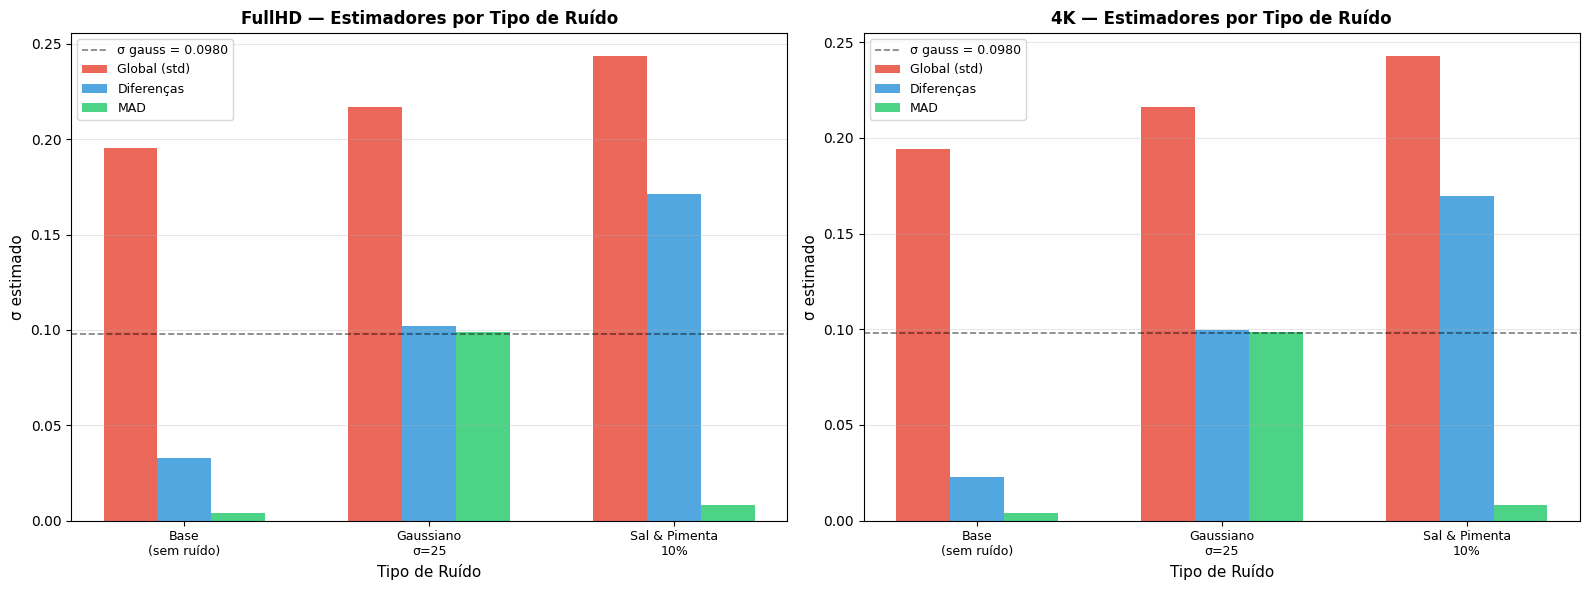

In [11]:
# grafico comparativo dos estimadores para cada tipo de ruido (FullHD)
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- FullHD ---
ax = axes[0]
categorias = ['Base\n(sem ruído)', 'Gaussiano\nσ=25', 'Sal & Pimenta\n10%']
x = np.arange(len(categorias))
largura = 0.22

v_global = [base_global_fhd, sigma_global_fhd, sp_global_fhd]
v_diff   = [base_diff_fhd, sigma_diff_fhd, sp_diff_fhd]
v_mad    = [base_mad_fhd, sigma_mad_fhd, sp_mad_fhd]

ax.bar(x - largura, v_global, largura, label='Global (std)', color='#e74c3c', alpha=0.85)
ax.bar(x,           v_diff,   largura, label='Diferenças',   color='#3498db', alpha=0.85)
ax.bar(x + largura, v_mad,    largura, label='MAD',          color='#2ecc71', alpha=0.85)

ax.axhline(y=sigma_verdadeiro, color='black', linestyle='--', linewidth=1.2, alpha=0.5, label=f'σ gauss = {sigma_verdadeiro:.4f}')
ax.set_xlabel('Tipo de Ruído', fontsize=11)
ax.set_ylabel('σ estimado', fontsize=11)
ax.set_title('FullHD — Estimadores por Tipo de Ruído', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categorias, fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# --- 4K ---
ax = axes[1]
v_global = [base_global_4k, sigma_global_4k, sp_global_4k]
v_diff   = [base_diff_4k, sigma_diff_4k, sp_diff_4k]
v_mad    = [base_mad_4k, sigma_mad_4k, sp_mad_4k]

ax.bar(x - largura, v_global, largura, label='Global (std)', color='#e74c3c', alpha=0.85)
ax.bar(x,           v_diff,   largura, label='Diferenças',   color='#3498db', alpha=0.85)
ax.bar(x + largura, v_mad,    largura, label='MAD',          color='#2ecc71', alpha=0.85)

ax.axhline(y=sigma_verdadeiro, color='black', linestyle='--', linewidth=1.2, alpha=0.5, label=f'σ gauss = {sigma_verdadeiro:.4f}')
ax.set_xlabel('Tipo de Ruído', fontsize=11)
ax.set_ylabel('σ estimado', fontsize=11)
ax.set_title('4K — Estimadores por Tipo de Ruído', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(categorias, fontsize=9)
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### Perguntas da Parte D

**4. Os estimadores foram projetados para ruído gaussiano. Eles funcionam bem para ruído sal-e-pimenta? Explique.**

> **O estimador diff superestima enormemente o ruído sal-e-pimenta**, porque esse tipo de ruído cria descontinuidades extremas entre pixels vizinhos (transições abruptas 0→1 ou 1→0). Como o estimador por diferenças calcula `std(diff)`, essas transições impulsivas inflam o desvio-padrão.
>
> O **MAD é significativamente mais robusto** ao ruído sal-e-pimenta do que o estimador diff. A mediana descarta naturalmente os valores extremos causados pelos impulsos de sal-e-pimenta (que são outliers). Porém, o valor retornado pelo MAD para sal-e-pimenta não tem a mesma interpretação direta de σ gaussiano — ele indica a "dispersão típica" das diferenças, excluindo outliers.
>
> O **estimador global** reflete a variabilidade total (cena + ruído impulsivo), e como o ruído sal-e-pimenta altera significativamente muitos pixels para valores extremos, o std global tende a crescer bastante.

**5. Por que o MAD é mais robusto que o estimador diff para ruído impulsivo?**

> A robustez do MAD vem do uso da **mediana** em vez da **média/desvio-padrão**. A mediana é um estimador de posição que ignora valores extremos (outliers). No caso do ruído sal-e-pimenta, os pixels corrompidos geram diferenças muito grandes entre vizinhos, mas como são apenas ~10% dos pixels, a mediana das diferenças absolutas não é afetada por eles. Já o desvio-padrão (usado no diff) é sensível a qualquer valor extremo, pois eleva ao quadrado os desvios — amplificando o efeito dos impulsos.


## Parte E: Comparação FullHD vs 4K — Influência da resolução

Vamos investigar se a resolução da imagem (número de pixels) influencia a precisão dos estimadores.

### E.1: Comparação direta


In [12]:
# comparacao direta FullHD vs 4K para ruido gaussiano
print('=== Comparação de Estimadores — Ruído Gaussiano σ=25 ===')
print(f'σ verdadeiro (normalizado): {sigma_verdadeiro:.4f}')
print()

dados_resolucao = {
    'Estimador': ['Global (std)', 'Diferenças', 'MAD'],
    'FullHD': [sigma_global_fhd, sigma_diff_fhd, sigma_mad_fhd],
    '4K': [sigma_global_4k, sigma_diff_4k, sigma_mad_4k],
    'Δ (4K - FullHD)': [
        sigma_global_4k - sigma_global_fhd,
        sigma_diff_4k - sigma_diff_fhd,
        sigma_mad_4k - sigma_mad_fhd
    ]
}

df_resolucao = pd.DataFrame(dados_resolucao)
print(df_resolucao.to_string(index=False, float_format='{:.4f}'.format))
print()

# numero de pixels em cada resolucao
n_pixels_fhd = fhd_base.shape[0] * fhd_base.shape[1]
n_pixels_4k  = k4_base.shape[0] * k4_base.shape[1]
print(f'Pixels FullHD: {n_pixels_fhd:,}')
print(f'Pixels 4K:     {n_pixels_4k:,}')
print(f'Razão 4K/FullHD: {n_pixels_4k / n_pixels_fhd:.2f}x')


=== Comparação de Estimadores — Ruído Gaussiano σ=25 ===
σ verdadeiro (normalizado): 0.0980

   Estimador  FullHD     4K  Δ (4K - FullHD)
Global (std)  0.2169 0.2159          -0.0010
  Diferenças  0.1022 0.0997          -0.0025
         MAD  0.0987 0.0987           0.0000

Pixels FullHD: 2,073,600
Pixels 4K:     8,294,400
Razão 4K/FullHD: 4.00x


### E.2: Histogramas do ruído estimado

Vamos visualizar a distribuição das diferenças entre pixels vizinhos para entender melhor o comportamento dos estimadores.


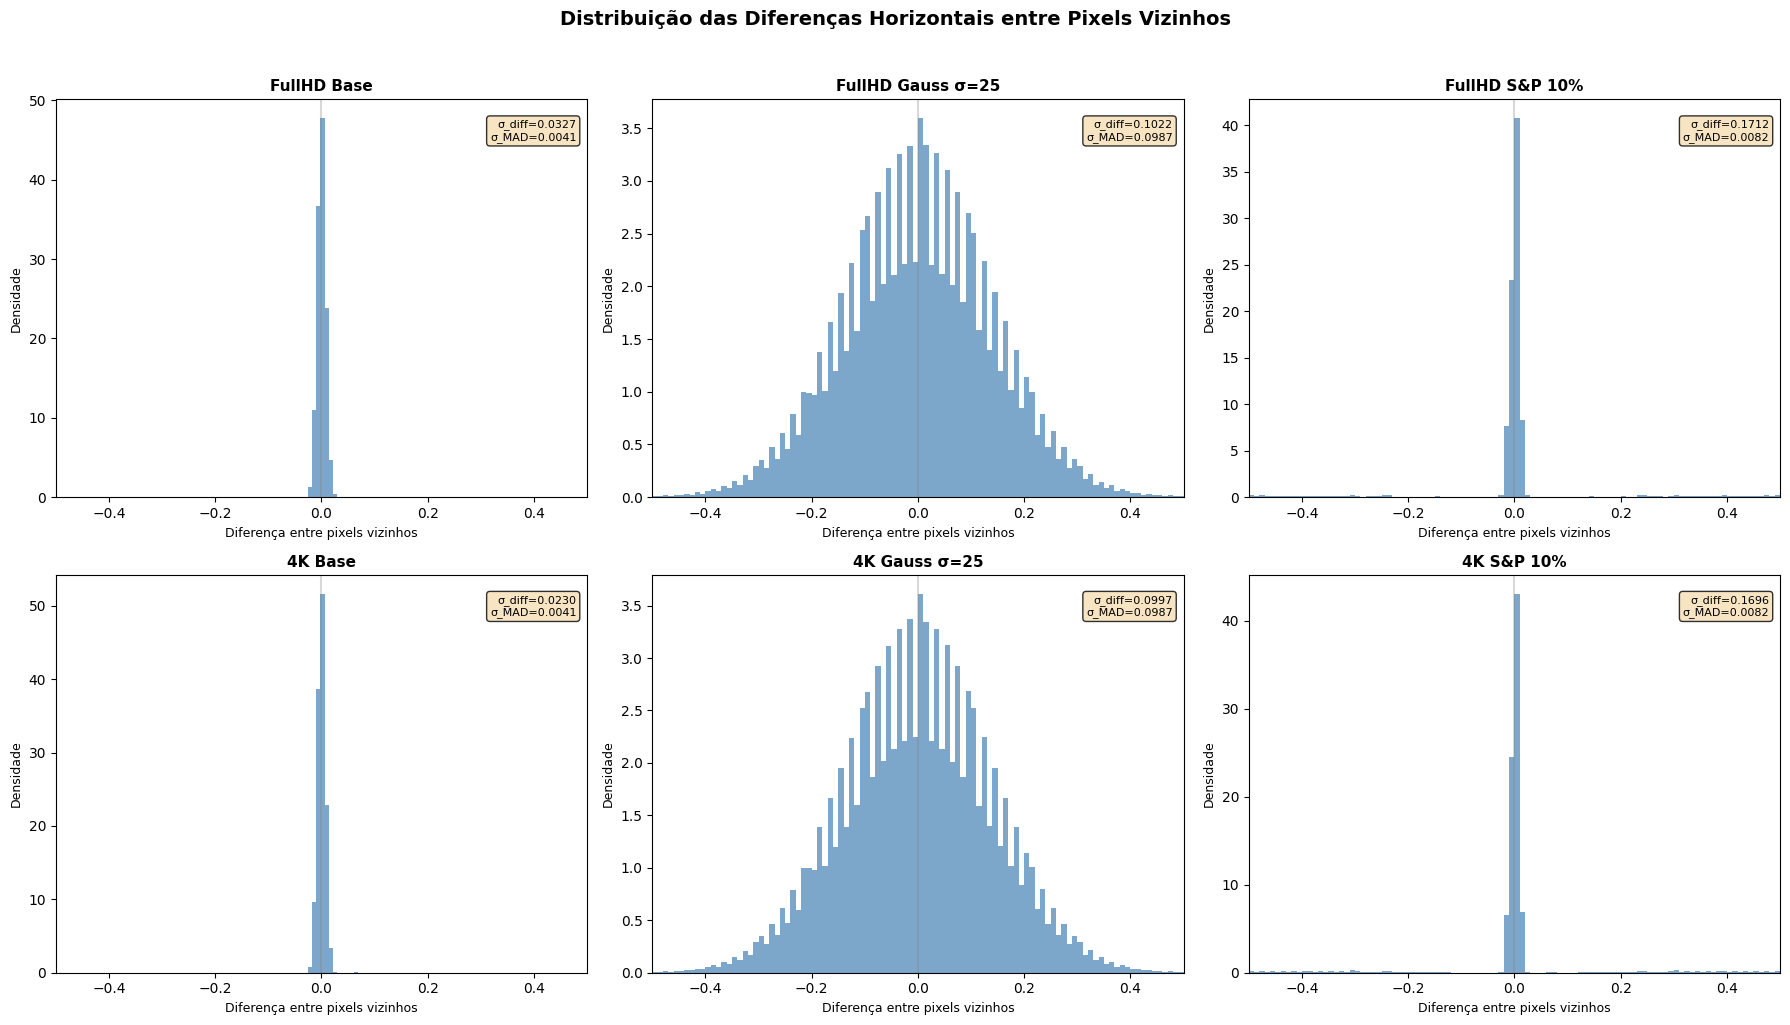

In [13]:
# histogramas das diferencas horizontais
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

imagens_todas = [
    (fhd_base, 'FullHD Base'),
    (fhd_gauss, 'FullHD Gauss σ=25'),
    (fhd_sp, 'FullHD S&P 10%'),
    (k4_base, '4K Base'),
    (k4_gauss, '4K Gauss σ=25'),
    (k4_sp, '4K S&P 10%'),
]

for ax, (img, titulo) in zip(axes.flat, imagens_todas):
    diffs = np.diff(img, axis=1).ravel()
    ax.hist(diffs, bins=200, density=True, alpha=0.7, color='steelblue', edgecolor='none')
    ax.set_title(titulo, fontsize=11, fontweight='bold')
    ax.set_xlabel('Diferença entre pixels vizinhos', fontsize=9)
    ax.set_ylabel('Densidade', fontsize=9)
    ax.set_xlim(-0.5, 0.5)
    
    # anota MAD e diff
    s_diff = estimar_sigma_diff(img)
    s_mad  = estimar_sigma_mad(img)
    ax.axvline(x=0, color='gray', linestyle='-', alpha=0.3)
    ax.text(0.98, 0.95, f'σ_diff={s_diff:.4f}\nσ_MAD={s_mad:.4f}',
            transform=ax.transAxes, fontsize=8, va='top', ha='right',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))

plt.suptitle('Distribuição das Diferenças Horizontais entre Pixels Vizinhos',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### Perguntas da Parte E

**6. A resolução da imagem afeta a precisão dos estimadores? De que forma?**

> Os estimadores tendem a ter **resultados muito similares** entre FullHD e 4K quando aplicados à mesma cena com o mesmo nível de ruído. Isso é esperado, pois os estimadores diff e MAD operam localmente (diferenças entre pixels vizinhos) e são independentes do número total de pixels. A resolução maior (4K = ~4× mais pixels que FullHD) fornece mais amostras para os cálculos estatísticos, o que pode tornar as estimativas marginalmente mais estáveis, mas o efeito é pequeno na prática.

**7. Observando os histogramas, o que diferencia o ruído gaussiano do sal-e-pimenta na distribuição das diferenças?**

> Para o **ruído gaussiano**, o histograma das diferenças tem formato de sino (gaussiano) centrado em zero — as diferenças seguem uma distribuição normal com desvio √2·σ. Para o **sal-e-pimenta**, o histograma apresenta um pico central estreito (pixels não afetados, cujas diferenças refletem apenas a estrutura da imagem) e **caudas pesadas** com valores extremos próximos de ±1 (transições abruptas 0↔valor ou valor↔1 causadas pelos impulsos). Essas caudas pesadas são outliers que inflam o estimador diff mas são descartados pelo MAD.


## Parte F: Fechamento e perguntas finais

### Resumo dos resultados


In [14]:
# tabela resumo final
print('=' * 80)
print('RESUMO FINAL — Estimação Cega de Ruído em Imagens Reais')
print('=' * 80)
print()
print(f'σ verdadeiro do ruído gaussiano (normalizado): {sigma_verdadeiro:.4f}')
print()
print(df_completo.to_string(index=False, float_format='{:.4f}'.format))
print()
print('=' * 80)
print()
print('Observações-chave:')
print('1. O estimador global (std) NUNCA serve para estimar ruído — ele mede a')
print('   variabilidade total da cena.')
print('2. O estimador diff funciona bem para ruído gaussiano, mas falha com')
print('   ruído impulsivo (sal-e-pimenta).')
print('3. O MAD é o estimador mais robusto: funciona bem para gaussiano e é')
print('   resiliente a outliers do sal-e-pimenta.')
print('4. A resolução da imagem (FullHD vs 4K) tem impacto mínimo na precisão')
print('   dos estimadores locais (diff e MAD).')
print('5. O efeito do clip (saturação em [0,1]) pode causar subestimação do σ')
print('   quando o ruído é forte.')


RESUMO FINAL — Estimação Cega de Ruído em Imagens Reais

σ verdadeiro do ruído gaussiano (normalizado): 0.0980

Resolução     Tipo de Ruído  global (std)   diff    MAD
   FullHD     Nenhum (base)        0.1954 0.0327 0.0041
   FullHD    Gaussiano σ=25        0.2169 0.1022 0.0987
   FullHD Sal & Pimenta 10%        0.2436 0.1712 0.0082
       4K     Nenhum (base)        0.1942 0.0230 0.0041
       4K    Gaussiano σ=25        0.2159 0.0997 0.0987
       4K Sal & Pimenta 10%        0.2427 0.1696 0.0082


Observações-chave:
1. O estimador global (std) NUNCA serve para estimar ruído — ele mede a
   variabilidade total da cena.
2. O estimador diff funciona bem para ruído gaussiano, mas falha com
   ruído impulsivo (sal-e-pimenta).
3. O MAD é o estimador mais robusto: funciona bem para gaussiano e é
   resiliente a outliers do sal-e-pimenta.
4. A resolução da imagem (FullHD vs 4K) tem impacto mínimo na precisão
   dos estimadores locais (diff e MAD).
5. O efeito do clip (saturação em [0,1]) po

### Perguntas finais

**8. Qual estimador você recomendaria na prática? Justifique.**

> O estimador **MAD** é o mais recomendado na prática. Ele é robusto a bordas e texturas da imagem (não superestima o ruído em regiões com alta variação de intensidade) e também é resiliente a ruído impulsivo (sal-e-pimenta). Diferentemente do estimador por diferenças, que usa o desvio-padrão (sensível a outliers), o MAD usa a mediana, que descarta naturalmente valores extremos. Isso o torna o **método padrão** em aplicações reais de processamento de imagens.

**9. Se você recebesse uma imagem sem saber que tipo de ruído ela contém, como procederia para estimar o nível de ruído?**

> Primeiro, aplicaria o estimador MAD na imagem inteira para obter uma estimativa geral do σ. Em seguida, compararia com o estimador diff: se ambos concordam, é provável que o ruído seja gaussiano. Se o diff retorna um valor muito maior que o MAD, provavelmente há componentes impulsivas (sal-e-pimenta) ou bordas muito fortes na imagem. Também examinaria o histograma das diferenças horizontais: um formato gaussiano indica ruído aditivo gaussiano, enquanto caudas pesadas indicam ruído impulsivo ou estrutura complexa na imagem.

**10. Os fatores 0,6745 e √2 usados no MAD parecem "mágicos". Explique sua origem.**

> Esses números têm origem clara na estatística:
> - **0,6745** é a razão entre o MAD e o σ para a distribuição normal padrão. Mais precisamente, se X ~ N(0, σ²), então MAD(X) = 0,6745·σ. Esse valor é tabelado em qualquer livro de estatística robusta e vem do fato de que, para uma gaussiana, a mediana dos desvios absolutos em relação à mediana é Φ⁻¹(3/4) ≈ 0,6745 vezes o desvio-padrão.
> - **√2** vem do mesmo raciocínio da técnica por diferenças: se dois pixels vizinhos têm ruído independente N(0, σ²), sua diferença tem variância 2σ², logo desvio-padrão √2·σ.
> - O fator combinado é **0,6745 × √2 ≈ 0,9539**, que aparece no denominador da fórmula do estimador MAD aplicado às diferenças.
